# PEtab in a notebook

[PEtab](https://petab.readthedocs.io/) is a community standard for describing a
parameter-estimation problem — model, conditions, observables, measurements, and
parameters — as a folder of tables plus a `problem.yaml`. PyBNF can **import** a
PEtab problem into a runnable job with one call, `pybnf.petab.import_job`, and this
notebook does exactly that, then fits the imported problem interactively.

We use the small BNGL PEtab problem that ships with tutorial lesson 12 (a Bateman
chain A → B → C).

In [1]:
import os, tempfile
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl; mpl.rcParams['figure.dpi'] = 80

os.environ.setdefault('BNGPATH', os.path.expanduser('~/Simulations/BioNetGen-2.9.3'))
import pybnf_notebook as nb

problem_ref = Path('../tutorial/12_petab_roundtrip/petab/problem.yaml')
problem = problem_ref.resolve()
print('PEtab problem:', problem_ref)
print('tables:', sorted(p.name for p in problem.parent.glob('*')))

PEtab problem: ../tutorial/12_petab_roundtrip/petab/problem.yaml
tables: ['bateman_chain.bngl', 'measurements.tsv', 'observables.tsv', 'parameters.tsv', 'problem.yaml']


## Import the problem

`import_job(problem_yaml, out_dir)` reads the PEtab tables and the model, reconstructs
the experiments' data, and writes a runnable PyBNF job: the `.exp` data file(s), a
verbatim copy of the model, and an `imported.conf`. The *problem* (parameters,
observables, measurements, conditions) is recovered exactly; the **run recipe**
(which algorithm, how many iterations) is left for us to choose — PEtab has no home
for it.

In [2]:
from pybnf.petab import import_job

IMPORTED = Path(tempfile.mkdtemp(prefix='pybnf_petab_'))
import_job(problem, IMPORTED, job_type='de')

print('imported files:', sorted(p.name for p in IMPORTED.glob('*')))
print('\n--- imported.conf ---')
print((IMPORTED / 'imported.conf').read_text())

imported files: ['bateman_chain.bngl', 'experiment1.exp', 'imported.conf']

--- imported.conf ---
# Imported from a PEtab v2 problem by pybnf.petab.import_job (#407).
# The PEtab *problem* (parameters/priors, observables/noise, measurements,
# conditions) is recovered exactly and round-trips through a re-export. The
# run-recipe below (job_type + algorithm settings, the per-experiment method:,
# and output/verbosity) is SUPPLIED, not recovered: PEtab is a problem spec with
# no home for the method, so it is not part of the round-trip identity.

output_dir=output/imported
edition = 2

model: bateman_chain.bngl
job_type = de
objective = sos

experiment: experiment1, method: ode, data: experiment1.exp

uniform_var = k1 0.05 3
uniform_var = k2 0.02 2

population_size = 50
max_iterations = 100
verbosity = 0



## Choose a run recipe and fit

The imported conf carries a generous default budget. For an interactive fit we
pick the in-process bngsim backend and a smaller budget — an ordinary text edit of
the run recipe, which is *not* part of the PEtab problem identity.

In [3]:
conf = (IMPORTED / 'imported.conf').read_text()
# Make the model/data paths absolute (so we needn't change directory), pick the
# in-process bngsim backend, and trim the budget for a quick interactive fit.
conf = conf.replace('model: bateman_chain.bngl',
                    f'model: {IMPORTED / "bateman_chain.bngl"}\nbngl_backend = bngsim')
conf = conf.replace('data: experiment1.exp', f'data: {IMPORTED / "experiment1.exp"}')
conf = conf.replace('population_size = 50', 'population_size = 20')
conf = conf.replace('max_iterations = 100', 'max_iterations = 30')

alg = nb.run_fit(conf, IMPORTED / 'out')
fit = nb.best_fit(alg)
print('fitted parameters:', {k: round(v, 4) for k, v in fit.items()})

Completed 10 of 30 iterations


Completed 20 of 30 iterations


Completed 30 of 30 iterations
Stop criterion satisfied with objective function value of 0.1371209496739197
fitted parameters: {'k1': 0.7982, 'k2': 0.251}


## Plot the fit against the imported data

The PEtab measurements were imported to `experiment1.exp`; `simulate` runs the model
at the fitted parameters. Data columns and model observables share names
(`Obs_A`/`Obs_B`/`Obs_C`), so overlaying them is direct.

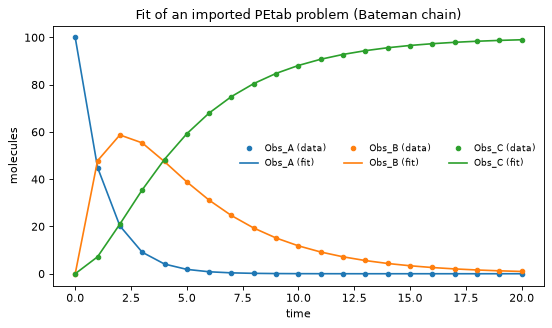

In [4]:
data = nb.load_exp(IMPORTED / 'experiment1.exp')
sim = nb.simulate(alg)

fig, ax = plt.subplots(figsize=(7, 4.2))
for obs, color in [('Obs_A', 'C0'), ('Obs_B', 'C1'), ('Obs_C', 'C2')]:
    ax.plot(data['time'], data[obs], 'o', ms=4, color=color, label=f'{obs} (data)')
    ax.plot(sim['time'], sim[obs], '-', color=color, label=f'{obs} (fit)')
ax.set(xlabel='time', ylabel='molecules', title='Fit of an imported PEtab problem (Bateman chain)')
ax.legend(frameon=False, ncol=3, fontsize=8); fig.tight_layout()

## Takeaways

- `pybnf.petab.import_job` turns any BNGL- or SBML-native PEtab v2 problem into a
  runnable PyBNF job; the reverse, `export_job`, round-trips a PyBNF fit back out to
  PEtab.
- The import recovers the *problem*; you supply the *run recipe*. Pass
  `job_type='all'` to emit one conf per optimizer/sampler, or `settings=...` to set
  the budget at import time instead of editing the conf.
- From here it is the same story as the quickstart: `run_fit`, read `best_fit`, plot.